# ANALYSIS

In [1]:
import numpy as np
import seaborn as sns
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd
import time

1. We add new feature - family = parch + siblings + 1

There will be less features, but it will reation the info.

2. We fill age with median values, because we lose large portion of data by dropping NaNs.

In [17]:
dataset = sns.load_dataset('titanic')

# add family feature
family = dataset['sibsp'] + dataset['parch'] + 1
family = pd.DataFrame(family, columns=['family'])

dataset = dataset.join(family)

#remove rows with nan
dataset["age"] = dataset["age"].fillna(dataset["age"].median())


# turn str features into numeric features
dataset['sex'] = dataset['sex'].map({'male' : 0, 'female' : 1})
dataset['alive'] = dataset['alive'].map({'yes' : 1, 'no' : 0})

print(dataset)
print(dataset.describe())


column_names = np.array(dataset.columns)
data = dataset.values


     survived  pclass  sex   age  sibsp  parch     fare embarked   class  \
0           0       3    0  22.0      1      0   7.2500        S   Third   
1           1       1    1  38.0      1      0  71.2833        C   First   
2           1       3    1  26.0      0      0   7.9250        S   Third   
3           1       1    1  35.0      1      0  53.1000        S   First   
4           0       3    0  35.0      0      0   8.0500        S   Third   
..        ...     ...  ...   ...    ...    ...      ...      ...     ...   
886         0       2    0  27.0      0      0  13.0000        S  Second   
887         1       1    1  19.0      0      0  30.0000        S   First   
888         0       3    1  28.0      1      2  23.4500        S   Third   
889         1       1    0  26.0      0      0  30.0000        C   First   
890         0       3    0  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town  alive  alone  family  
0      man        True

## Exploration of features

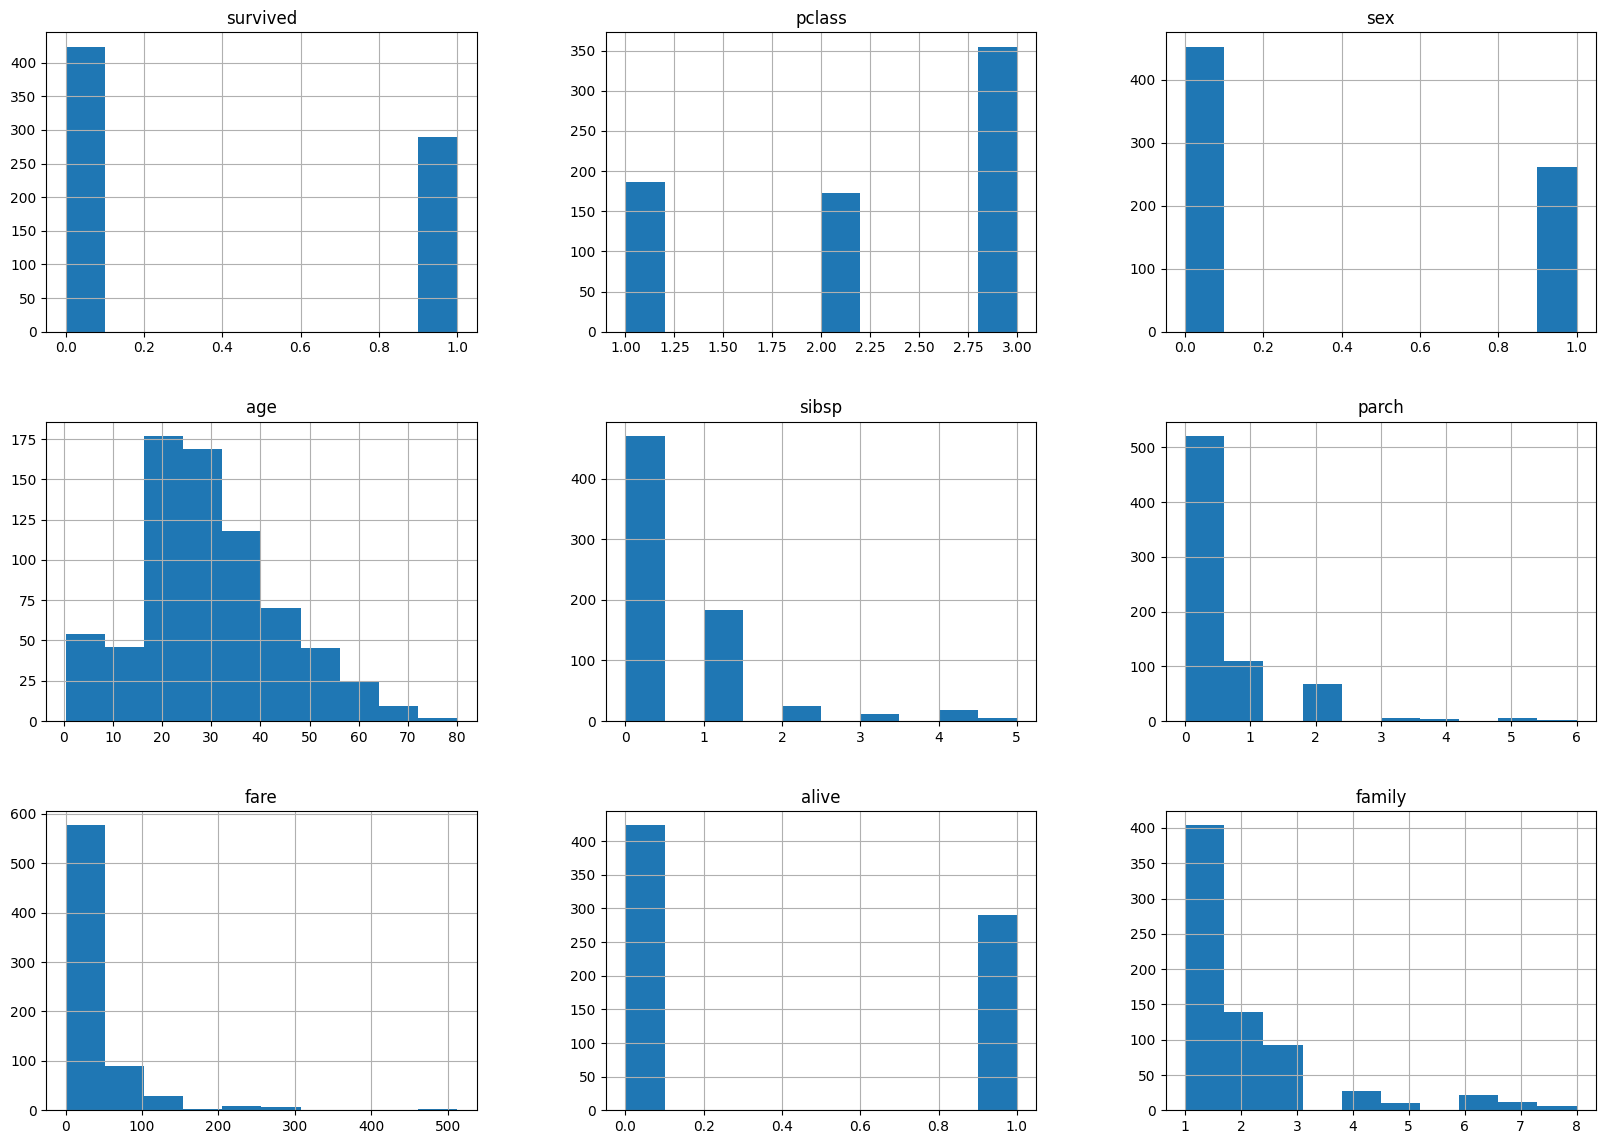

In [3]:
_ = dataset.hist(figsize=(20, 14))

### Survivors Male vs Female

Amount of female-survivors is *2 time bigger* than amount of male-survivors, since women are a priority.

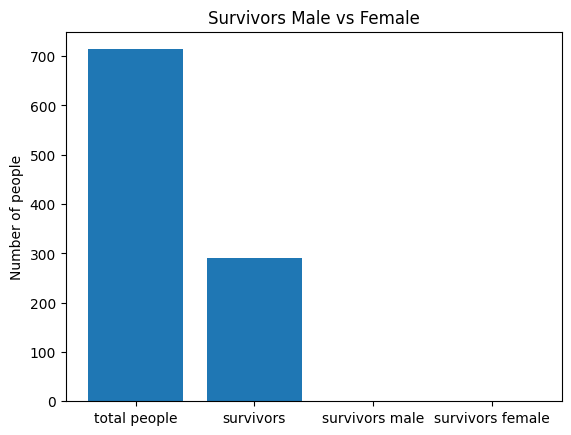

In [4]:
total_people = data.shape[0]
total_survivors = sum(data[:, 0])
total_survivors_male = sum(row[0] for row in data if row[2] == 'male')
total_survivors_female = sum(row[0] for row in data if row[2] == 'female')

plt.bar(['total people', 'survivors', 'survivors male', 'survivors female'],
        [total_people, total_survivors, total_survivors_male, total_survivors_female])
plt.ylabel('Number of people')
plt.title('Survivors Male vs Female')
plt.show()

### Age distribution

Young and healthy people had better chances at survival than old. 
Also old could have given their places on boats to younger people,
who have a long live ahead or a family, that depends on them.




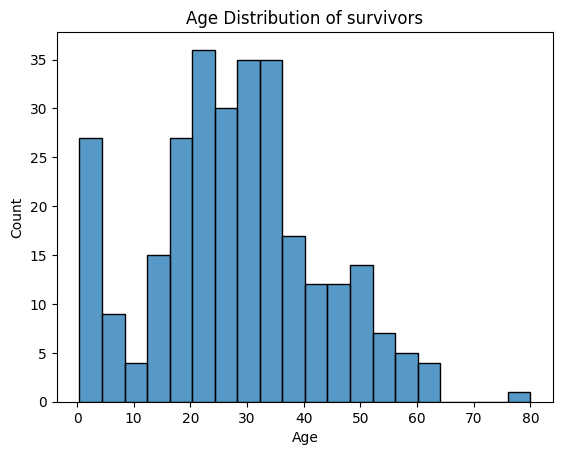

In [5]:
ages = [row[3] for row in data if row[0] == 1]

sns.histplot(ages, bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of survivors")

plt.show()

### Survivors' wealth

The more wealth you have, the better chances of survival you have.

The reason could be, that better classes are nearer to the surface, where people had much better chances of getting out alive.

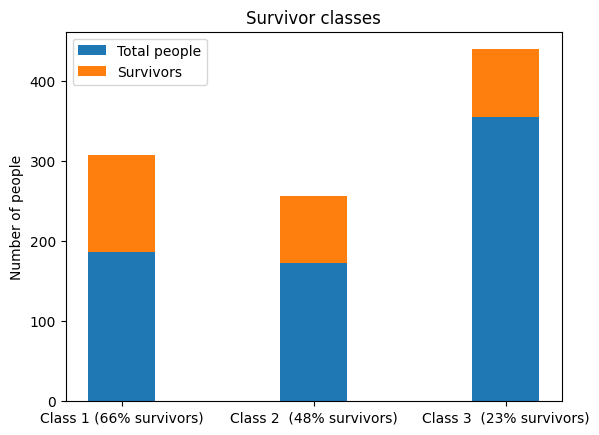

In [6]:
first_class_total = sum([1 for row in data if row[1] == 1])
second_class_total = sum([1 for row in data if row[1] == 2])
third_class_total = sum([1 for row in data if row[1] == 3])

first_class_survivors = sum([row[0] for row in data if row[1] == 1])
second_class_survivors = sum([row[0] for row in data if row[1] == 2])
third_class_survivors = sum([row[0] for row in data if row[1] == 3])

percentage1 = int(round(first_class_survivors /  first_class_total, 2) * 100)
percentage2 = int(round(second_class_survivors /  second_class_total, 2) * 100)
percentage3 = int(round(second_class_survivors /  third_class_total, 2) * 100)

width = 0.35

plt.bar(['Class 1 (' + str(percentage1) + '% survivors)', 'Class 2  (' + str(percentage2) + '% survivors)', 'Class 3  (' + str(percentage3) + '% survivors)'],
        [first_class_total, second_class_total, third_class_total],
        width,
        label='Total people',)
plt.bar(['Class 1 (' + str(percentage1) + '% survivors)', 'Class 2  (' + str(percentage2) + '% survivors)', 'Class 3  (' + str(percentage3) + '% survivors)'],
        [first_class_survivors, second_class_survivors, third_class_survivors],
        width,
        bottom = [first_class_total, second_class_total, third_class_total],
        label='Survivors')

plt.ylabel('Number of people')
plt.title('Survivor classes')
plt.legend()
plt.show()

### Feature correlation


Features, that correlate the most with survival chances are:
- Passenger class
- Sex
- Age
- Amount of children and parents
- Fare
- Adult male
- Being alone

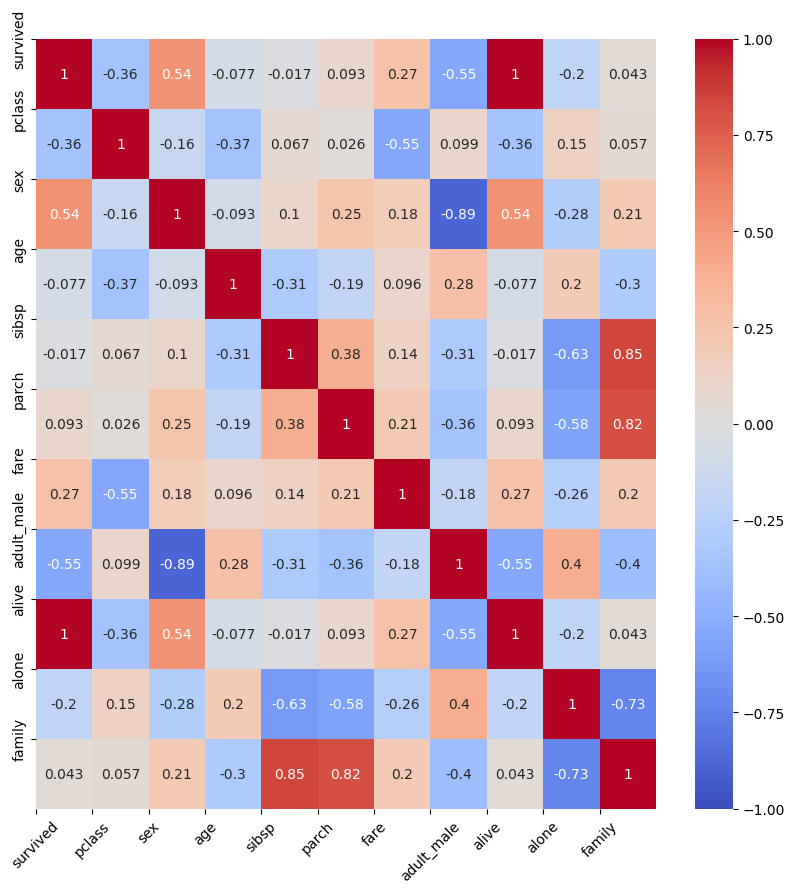

In [7]:
corr = dataset.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

# Train model to predict survival

As we saw in visualizations the data is pretty complex. That means, that we need to use a prediction model.

## Model Selection

### KNN
We need to predict binary value, so let's try K nearest neighbors first.

In [19]:
df_numeric = dataset.drop(columns=['embarked', 'class', 'who', 'deck', 'embark_town'])

X = df_numeric.drop(columns=['survived', 'sibsp', 'parch', 'alive'])
y = df_numeric['survived']

# split data
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.33, random_state=1)

from sklearn.model_selection import cross_validate
from sklearn.model_selection import ShuffleSplit

Mean score: 0.826


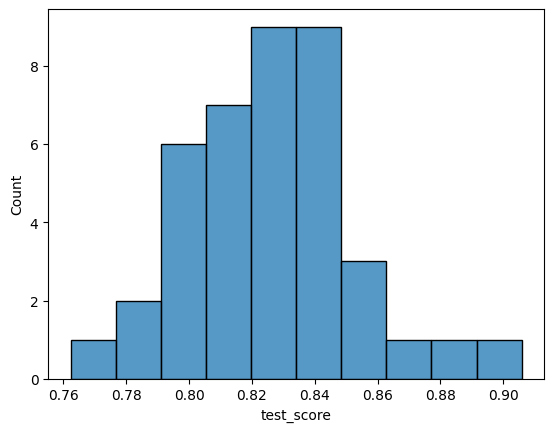

In [30]:
# make pipeline

model = make_pipeline(StandardScaler(), KNeighborsClassifier())

#cross validation
cv = ShuffleSplit(n_splits=40, test_size = 0.25, random_state=0)
cross_validation_results = cross_validate(
    model, X, y, cv=cv, scoring="accuracy")

results = pd.DataFrame(cross_validation_results)
sns.histplot(results["test_score"], bins=10)
print(f"Mean score: {results["test_score"].mean():.3f}")

This is good, but not enough. So we will try Logistic Regression next.

### Logistic Regression

Mean score: 0.825


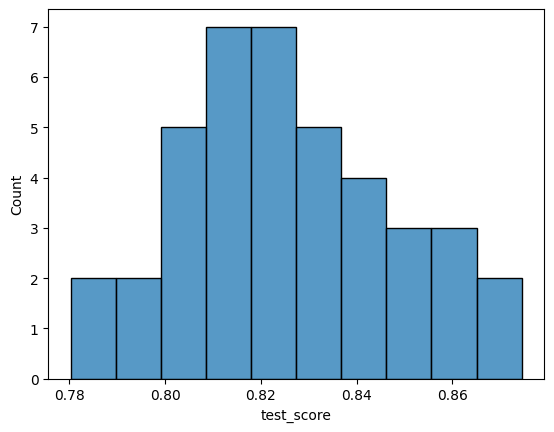

In [31]:
#make pipeline
model = make_pipeline(StandardScaler(), LogisticRegression())

#cross validation
cv = ShuffleSplit(n_splits=40, test_size = 0.25, random_state=0)
cross_validation_results = cross_validate(
    model, X, y, cv=cv, scoring="accuracy")

results = pd.DataFrame(cross_validation_results)
_ = sns.histplot(results["test_score"], bins=10)
print(f"Mean score: {results["test_score"].mean():.3f}")

Logistic regression is not better. It seems the data is even more complex, than I initially thought. Let's try decision tree.

### Decision Tree

Mean score: 0.787


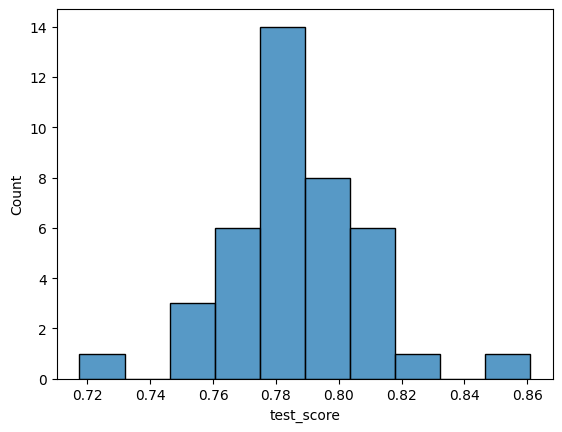

In [32]:
from sklearn.tree import DecisionTreeClassifier

model = make_pipeline(DecisionTreeClassifier())

#cross validation
cv = ShuffleSplit(n_splits=40, test_size = 0.25, random_state=0)
cross_validation_results = cross_validate(
    model, X, y, cv=cv, scoring="accuracy")

results = pd.DataFrame(cross_validation_results)
_ = sns.histplot(results["test_score"], bins=10)
print(f"Mean score: {results["test_score"].mean():.3f}")

This works even worse.

### Random Forest Classifier

Mean score: 0.832


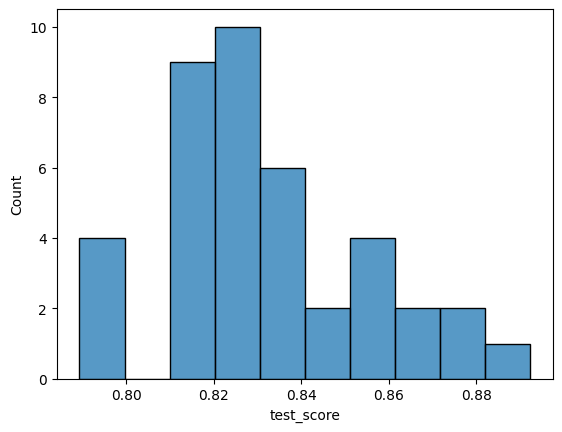

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = make_pipeline(
    RandomForestClassifier( 
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        random_state=0
))

#cross validation
cv = ShuffleSplit(n_splits=40, test_size = 0.25, random_state=0)
cross_validation_results = cross_validate(
    model, X, y, cv=cv, scoring="accuracy")

results = pd.DataFrame(cross_validation_results)
_ = sns.histplot(results["test_score"], bins=10)
print(f"Mean score: {results["test_score"].mean():.3f}")

Looks better. Let's try tuning hyperparameters.

## Tuning Hyperparameters